# Notebook 3: Deep Q-Network (DQN) — Online Intrusion Detection Agent

**Research Hypothesis:**  
A DQN agent that receives network flow features as states and classifies each
flow as benign/attack as an action — rewarded online — can adapt to concept
drift without access to a static training set.

## MDP Formulation

| Component | Definition |
|-----------|------------|
| **State** s_t | Normalised feature vector of flow t (dim=78) |
| **Action** a_t | {0=Benign, 1=Attack} |
| **Reward** r_t | +1 correct classification, -1 misclassification, -0.5 FP penalty |
| **Transition** | s_{t+1} = next flow in stream (episodic — no env dynamics) |
| **Episode** | A contiguous block of EPISODE_LEN flows |

## Architecture
- Double DQN (DDQN) with target network soft-updates
- Dueling network heads (advantage + value)
- Prioritised Experience Replay (PER)
- ε-greedy decay schedule

---

## 0. Dependencies

In [24]:
!pip install torch numpy scikit-learn matplotlib seaborn tqdm pandas -q

## 1. Imports

In [25]:
import warnings, time, json, collections, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path
from tqdm.auto import tqdm
from collections import deque
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    confusion_matrix, roc_auc_score
)

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {DEVICE}')

PROC    = Path('processed')
FIGS    = Path('figures');  FIGS.mkdir(exist_ok=True)
SAVES   = Path('models');   SAVES.mkdir(exist_ok=True)
RESULTS = Path('results');  RESULTS.mkdir(exist_ok=True)

Using device: cpu


## 2. Load Artefacts

In [26]:
X_stream = np.load(PROC / 'X_stream.npy').astype(np.float32)
y_stream = np.load(PROC / 'y_stream.npy').astype(int)

# DQN also sees the training split only for warm-start replay
# (comment out to run fully cold — no prior data)
X_train = np.load(PROC / 'X_train.npy').astype(np.float32)
y_train = np.load(PROC / 'y_train.npy').astype(int)

STATE_DIM = X_stream.shape[1]
N_ACTIONS = 2  # 0=benign, 1=attack
N = len(X_stream)

print(f'Stream: {X_stream.shape}  |  State dim: {STATE_DIM}')

Stream: (1946025, 78)  |  State dim: 78


## 3. Dueling DDQN Architecture

In [27]:
class DuelingDQN(nn.Module):
    """
    Dueling Deep Q-Network with separate value V(s) and
    advantage A(s,a) streams.
    
    Q(s,a) = V(s) + A(s,a) - mean_a'[A(s,a')]
    """
    def __init__(self, state_dim: int, n_actions: int,
                 hidden: tuple = (256, 128, 64)):
        super().__init__()
        # Shared feature extraction backbone
        layers = []
        in_dim = state_dim
        for h in hidden:
            layers += [nn.Linear(in_dim, h), nn.LayerNorm(h), nn.ELU()]
            in_dim = h
        self.backbone = nn.Sequential(*layers)

        # Value stream
        self.value_stream = nn.Sequential(
            nn.Linear(in_dim, 64), nn.ELU(),
            nn.Linear(64, 1)
        )
        # Advantage stream
        self.advantage_stream = nn.Sequential(
            nn.Linear(in_dim, 64), nn.ELU(),
            nn.Linear(64, n_actions)
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        feat = self.backbone(x)
        V = self.value_stream(feat)
        A = self.advantage_stream(feat)
        Q = V + (A - A.mean(dim=1, keepdim=True))
        return Q


# Quick sanity check
net_test = DuelingDQN(STATE_DIM, N_ACTIONS, hidden=(512, 256, 128))  # Larger network
x_dummy = torch.zeros(4, STATE_DIM)
q_dummy = net_test(x_dummy)
print(f'Network output shape: {q_dummy.shape}  (batch=4, actions=2)')  
print(f'Total parameters: {sum(p.numel() for p in net_test.parameters()):,}')

Network output shape: torch.Size([4, 2])  (batch=4, actions=2)
Total parameters: 223,171


## 4. Prioritised Experience Replay (PER)

In [28]:
class SumTree:
    """Segment tree for O(log n) proportional sampling."""
    def __init__(self, capacity: int):
        self.capacity = capacity
        # Tree size is 2 * capacity - 1, but we use 2 * capacity for easier 1-based indexing logic
        self.tree = np.zeros(2 * capacity, dtype=np.float32)
        self.data = [None] * capacity
        self.ptr  = 0
        self.size = 0

    def _propagate(self, idx: int, delta: float):
        parent = (idx - 1) // 2
        self.tree[parent] += delta
        if parent != 0: 
            self._propagate(parent, delta)

    def _retrieve(self, idx: int, s: float) -> int:
        left = 2 * idx + 1
        right = left + 1
        if left >= len(self.tree): 
            return idx
        
        if s <= self.tree[left]:
            return self._retrieve(left, s)
        else:
            # Add a small epsilon check to prevent going out of bounds due to float precision
            return self._retrieve(right, max(0.0, s - self.tree[left]))

    @property
    def total(self) -> float:
        return float(self.tree[0])

    def add(self, priority: float, data):
        # Leaves start at index capacity - 1
        idx = self.ptr + self.capacity - 1
        self.data[self.ptr] = data
        self.update(idx, priority)
        self.ptr = (self.ptr + 1) % self.capacity
        self.size = min(self.size + 1, self.capacity)

    def update(self, idx: int, priority: float):
        delta = priority - self.tree[idx]
        self.tree[idx] = priority
        self._propagate(idx, delta)

    def get(self, s: float):
        idx = self._retrieve(0, s)
        # Ensure idx is within the leaf range
        idx = min(idx, len(self.tree) - 1)
        data_idx = idx - self.capacity + 1
        # Final safety clip for data_idx
        data_idx = max(0, min(data_idx, self.capacity - 1))
        return idx, self.tree[idx], self.data[data_idx]


class PrioritisedReplayBuffer:
    """PER buffer with importance-sampling weights."""
    def __init__(self, capacity: int, alpha: float = 0.8, beta: float = 0.4,
                 beta_increment: float = 0.001, eps: float = 1e-6):
        self.tree = SumTree(capacity)
        self.alpha = alpha
        self.beta  = beta
        self.beta_increment = beta_increment
        self.eps   = eps
        self.max_priority = 1.0

    def push(self, transition):
        self.tree.add(self.max_priority ** self.alpha, transition)

    def sample(self, batch_size: int):
        batch, indices, priorities = [], [], []
        segment = self.tree.total / batch_size
        self.beta = min(1.0, self.beta + self.beta_increment)

        for i in range(batch_size):
            a, b = segment * i, segment * (i + 1)
            s = random.uniform(a, b)
            idx, priority, data = self.tree.get(s)
            
            # The tree can return None if the buffer isn't full yet
            if data is None:
                # Fallback: grab a random index that DOES have data
                idx_rand = random.randint(0, self.tree.size - 1)
                data = self.tree.data[idx_rand]
                priority = self.tree.tree[idx_rand + self.tree.capacity - 1]
                idx = idx_rand + self.tree.capacity - 1

            batch.append(data)
            indices.append(idx)
            priorities.append(priority + self.eps)

        probs = np.array(priorities) / (self.tree.total + self.eps)
        weights = (self.tree.size * probs) ** (-self.beta)
        weights /= (weights.max() + 1e-9)

        return batch, indices, torch.FloatTensor(weights).to(DEVICE)

    def update_priorities(self, indices, td_errors):
        for idx, err in zip(indices, td_errors):
            priority = (abs(float(err)) + self.eps) ** self.alpha
            self.max_priority = max(self.max_priority, priority)
            self.tree.update(idx, priority)

    def __len__(self):
        return self.tree.size

print('PER buffer defined with stability fixes.')

PER buffer defined with stability fixes.


## 5. DQN Agent

In [35]:
class DQNAgent:
    """
    Double Dueling DQN with Dual-Buffer Balanced Replay.
    Integrated with Save/Load methods for persistence.
    """
    # ── Hyperparameters ──────────────────────────────────────────────────────
    GAMMA         = 0.95        
    LR            = 1e-4        
    BATCH         = 512         
    REPLAY_CAP    = 50_000
    TAU           = 0.005       
    EPS_START     = 1.0
    EPS_END       = 0.1         
    EPS_DECAY     = 50_000      
    WARMUP        = 2_000       
    LEARN_EVERY   = 2           
    ATTACK_WEIGHT = 20.0        
    
    FN_PENALTY    = -100.0      
    FP_PENALTY    = -2.0        
    Q_BIAS        = 2.0         

    def __init__(self, state_dim: int, n_actions: int):
        self.n_actions = n_actions
        self.state_dim = state_dim
        self.steps = 0

        self.online  = DuelingDQN(state_dim, n_actions, hidden=(512, 256, 128)).to(DEVICE)
        self.target  = DuelingDQN(state_dim, n_actions, hidden=(512, 256, 128)).to(DEVICE)
        self.target.load_state_dict(self.online.state_dict())
        self.target.eval()

        self.optimiser = optim.Adam(self.online.parameters(), lr=self.LR)
        self.scheduler = optim.lr_scheduler.CosineAnnealingLR(
            self.optimiser, T_max=100_000, eta_min=1e-5
        )
        
        self.memory = PrioritisedReplayBuffer(self.REPLAY_CAP)
        self.attack_memory = collections.deque(maxlen=self.REPLAY_CAP // 2)
        self.losses = []

    @property
    def epsilon(self) -> float:
        return self.EPS_END + (self.EPS_START - self.EPS_END) * \
               np.exp(-self.steps / self.EPS_DECAY)

    def act(self, state: np.ndarray) -> int:
        if random.random() < self.epsilon:
            if random.random() < 0.4: return 1 
            return random.randint(0, self.n_actions - 1)
        
        s = torch.FloatTensor(state).unsqueeze(0).to(DEVICE)
        with torch.no_grad():
            q_values = self.online(s)
            q_values[0, 1] += self.Q_BIAS 
            return int(q_values.argmax(dim=1).item())

    def predict(self, state: np.ndarray) -> int:
        s = torch.FloatTensor(state).unsqueeze(0).to(DEVICE)
        with torch.no_grad():
            q_values = self.online(s)
            q_values[0, 1] += self.Q_BIAS 
            return int(q_values.argmax(dim=1).item())

    def compute_reward(self, action: int, label: int) -> float:
        if action == label:
            return self.ATTACK_WEIGHT if label == 1 else 1.0
        return self.FN_PENALTY if label == 1 else self.FP_PENALTY

    def remember(self, s, a, r, s_next, done, label):
        self.memory.push((s, a, r, s_next, done))
        if label == 1:
            self.attack_memory.append((s, a, r, s_next, done))

    def learn(self) -> float:
        if len(self.memory) < self.WARMUP or len(self.attack_memory) < self.BATCH // 2:
            return 0.0

        half = self.BATCH // 2
        batch_gen, idx_gen, weights_gen = self.memory.sample(half)
        batch_atk = random.sample(list(self.attack_memory), half)
        
        batch = batch_gen + batch_atk
        is_weights = torch.cat([weights_gen, torch.ones(half).to(DEVICE)])

        states  = torch.FloatTensor(np.vstack([e[0] for e in batch])).to(DEVICE)
        actions = torch.LongTensor([e[1] for e in batch]).unsqueeze(1).to(DEVICE)
        rewards = torch.FloatTensor([e[2] for e in batch]).unsqueeze(1).to(DEVICE)
        nexts   = torch.FloatTensor(np.vstack([e[3] for e in batch])).to(DEVICE)
        dones   = torch.FloatTensor([e[4] for e in batch]).unsqueeze(1).to(DEVICE)

        with torch.no_grad():
            best_a = self.online(nexts).argmax(dim=1, keepdim=True)
            q_next = self.target(nexts).gather(1, best_a)
            q_target = rewards + self.GAMMA * q_next * (1 - dones)

        q_pred = self.online(states).gather(1, actions)
        td_errors = (q_target - q_pred).detach().cpu().numpy().flatten()

        loss = (is_weights.unsqueeze(1) * F.smooth_l1_loss(q_pred, q_target, reduction='none')).mean()

        self.optimiser.zero_grad(); loss.backward()
        nn.utils.clip_grad_norm_(self.online.parameters(), 5.0); self.optimiser.step()
        self.scheduler.step()

        self.memory.update_priorities(idx_gen, td_errors[:half])
        for p_tgt, p_on in zip(self.target.parameters(), self.online.parameters()):
            p_tgt.data.copy_(self.TAU * p_on.data + (1 - self.TAU) * p_tgt.data)

        self.losses.append(float(loss.item()))
        return float(loss.item())

    # ── Save and Load Methods ────────────────────────────────────────────────
    def save(self, path: Path):
        """Saves the current state of the networks and optimizer."""
        torch.save({
            'online': self.online.state_dict(),
            'target': self.target.state_dict(),
            'optimiser': self.optimiser.state_dict(),
            'steps': self.steps
        }, path)

    def load(self, path: Path):
        """Loads a saved state into the networks and optimizer."""
        if not path.exists():
            print(f"Warning: No checkpoint found at {path}")
            return
        ckpt = torch.load(path, map_location=DEVICE)
        self.online.load_state_dict(ckpt['online'])
        self.target.load_state_dict(ckpt['target'])
        self.optimiser.load_state_dict(ckpt['optimiser'])
        self.steps = ckpt.get('steps', 0)

## 6. Warm-Start Replay Population

We optionally seed the replay buffer with a small fraction of the
training set transitions.  
This does **NOT** give the DQN labelled training access in the same way
as the ML models — it simply jump-starts the replay and avoids random
exploration in the first few thousand steps.

In [30]:
# Initialize agent
agent = DQNAgent(STATE_DIM, N_ACTIONS)

# Target 5,000 samples for the initial buffer
WARM_SAMPLES = min(5000, len(X_train))
warm_idx = np.random.choice(len(X_train), WARM_SAMPLES, replace=False)

for i in warm_idx:
    s      = X_train[i]
    label  = int(y_train[i])
    
    # Simulate random action for diversity
    a      = random.randint(0, 1)
    r      = agent.compute_reward(a, label)
    
    # Next state (random transition for MDP flow)
    j      = random.randint(0, len(X_train)-1)
    s_next = X_train[j]
    
    # CRITICAL: Pass 'label' so the agent can fill its attack-specific buffer
    agent.remember(s, a, r, s_next, False, label)

print(f"Replay buffer warm-started.")
print(f"Total Transitions: {len(agent.memory):,}")
print(f"Attack Samples in Buffer: {len(agent.attack_memory):,}")

Replay buffer warm-started.
Total Transitions: 5,000
Attack Samples in Buffer: 1,630


## 7. Online Streaming Training + Evaluation

The agent processes **every sample in the stream once, in order**.  
At each step:
1. Agent observes state s_t  
2. Agent selects action a_t (ε-greedy)  
3. Environment reveals true label → compute reward r_t  
4. Transition stored in PER buffer  
5. Every LEARN_EVERY steps → gradient update

In [ ]:
# ── 7. Online Streaming Training + Evaluation ───────────────────────────────

# --- Data Preparation ---
MAX_STREAM = 200_000   # cap for speed

# Implement shuffling to ensure a mix of classes from the start of the stream
indices = np.arange(len(X_stream))
np.random.seed(42) 
np.random.shuffle(indices)

# Select the shuffled subset
eval_idx = indices[:MAX_STREAM]
X_eval, y_eval = X_stream[eval_idx], y_stream[eval_idx]

print(f'Stream prepared with {MAX_STREAM:,} shuffled samples.')
print(f'Total Attacks in Window: {int(y_eval.sum()):,}')

N_EVAL = len(X_eval)
LOG_INTERVAL = 2_000

# Pre-allocate tracking arrays
preds_dqn   = np.zeros(N_EVAL, dtype=int)
rewards_log = np.zeros(N_EVAL, dtype=float)
eps_log     = np.zeros(N_EVAL, dtype=float)
loss_log    = np.zeros(N_EVAL, dtype=float)
rolling_acc = np.zeros(N_EVAL, dtype=float)

correct_count = 0
current_loss = 0.0
t0 = time.perf_counter()

# ── Main Training Loop ──────────────────────────────────────────────────────
for t in tqdm(range(N_EVAL), desc='DQN Stream', ncols=90):
    s     = X_eval[t]
    label = int(y_eval[t])

    # 1. Agent selects action
    a = agent.act(s)
    preds_dqn[t] = a

    # 2. Environment reveals reward
    r = agent.compute_reward(a, label)
    rewards_log[t] = r
    correct_count += (a == label)
    rolling_acc[t] = correct_count / (t + 1)

    # 3. Next state (sequential flow in shuffled stream)
    s_next = X_eval[min(t + 1, N_EVAL - 1)]
    done   = (t == N_EVAL - 1)

    # 4. Store in memory with label to enable balanced sampling
    agent.remember(s, a, r, s_next, done, label)
    agent.steps += 1

    # 5. Perform learning step
    if agent.steps % agent.LEARN_EVERY == 0:
        current_loss = agent.learn()
        loss_log[t]  = current_loss
    else:
        loss_log[t]  = current_loss

    eps_log[t] = agent.epsilon

    # 6. Periodic Logging
    if (t + 1) % LOG_INTERVAL == 0:
        # Calculate windowed F1 to monitor "Attack" detection progress
        win_start = max(0, t - LOG_INTERVAL)
        seg_f1 = f1_score(y_eval[win_start : t+1], 
                          preds_dqn[win_start : t+1], 
                          zero_division=0)
        
        tqdm.write(f'  Step {t+1:>6,}  |  CumAcc={rolling_acc[t]:.4f}  '
                   f'WinF1={seg_f1:.4f}  ε={agent.epsilon:.4f}')

elapsed = time.perf_counter() - t0


print(f'\nDQN training + evaluation completed in {elapsed:.1f}s')

Stream prepared with 200,000 shuffled samples.
Total Attacks in Window: 47,449


DQN Stream:   1%|▎                                  | 2010/200000 [00:25<47:41, 69.18it/s]

  Step  2,000  |  CumAcc=0.3905  WinF1=0.3400  ε=0.9647


DQN Stream:   2%|▋                                  | 4012/200000 [00:55<42:48, 76.30it/s]

  Step  4,000  |  CumAcc=0.4002  WinF1=0.3635  ε=0.9308


...

DQN Stream:  99%|████████████████████████████████▋| 198007/200000 [54:59<00:30, 65.60it/s]

  Step 198,000  |  CumAcc=0.7757  WinF1=0.8264  ε=0.1172


DQN Stream: 100%|█████████████████████████████████| 200000/200000 [55:30<00:00, 60.06it/s]


  Step 200,000  |  CumAcc=0.7770  WinF1=0.8478  ε=0.1165


AttributeError: 'DQNAgent' object has no attribute 'save'

In [36]:
# Create a new cell and run this to save your progress NOW
torch.save({
    'online': agent.online.state_dict(),
    'target': agent.target.state_dict(),
    'optimiser': agent.optimiser.state_dict(),
    'steps': agent.steps
}, SAVES / 'dqn_agent.pt')

print("✅ Agent weights saved manually.")

✅ Agent weights saved manually.


## 8. DQN Metrics

In [37]:
# Slice arrays to include only the steps actually processed (t)
acc_dqn   = accuracy_score(y_eval[:t], preds_dqn[:t])
prec_dqn  = precision_score(y_eval[:t], preds_dqn[:t], zero_division=0)
rec_dqn   = recall_score(y_eval[:t], preds_dqn[:t], zero_division=0)
f1_dqn    = f1_score(y_eval[:t], preds_dqn[:t], zero_division=0)
cm_dqn    = confusion_matrix(y_eval[:t], preds_dqn[:t])
tn, fp, fn, tp = cm_dqn.ravel() if cm_dqn.size == 4 else (0,0,0,0)
fpr_dqn   = fp / (fp + tn + 1e-9)

# AUC: use reward as proxy confidence (not ideal but informative)
try:
    auc_dqn = roc_auc_score(y_eval[:t], preds_dqn[:t])
except:
    auc_dqn = 0.5

dqn_summary = {
    'acc': acc_dqn, 'precision': prec_dqn, 'recall': rec_dqn,
    'f1': f1_dqn, 'auc': auc_dqn, 'fpr': fpr_dqn,
    'inference_time': elapsed, 'train_time': 0.0
}

with open(RESULTS / 'dqn_summary.json', 'w') as f:
    json.dump(dqn_summary, f, indent=2)

# Change these lines in Cell 24:
np.save(RESULTS / 'dqn_preds.npy', preds_dqn[:t]) # Use [:t]
np.save(RESULTS / 'dqn_rolling_acc.npy', rolling_acc[:t])
np.save(RESULTS / 'dqn_rewards.npy', rewards_log[:t])
np.save(RESULTS / 'dqn_loss.npy', loss_log[:t])
np.save(RESULTS / 'y_eval.npy', y_eval[:t]) # Crucial: Save the labels we actually used

print('DQN Metrics:')
for k, v in dqn_summary.items():
    print(f'  {k:20s}: {v:.4f}')

DQN Metrics:
  acc                 : 0.7770
  precision           : 0.5172
  recall              : 0.9048
  f1                  : 0.6582
  auc                 : 0.8211
  fpr                 : 0.2627
  inference_time      : 3330.1240
  train_time          : 0.0000


## 9. DQN-Specific Visualisations

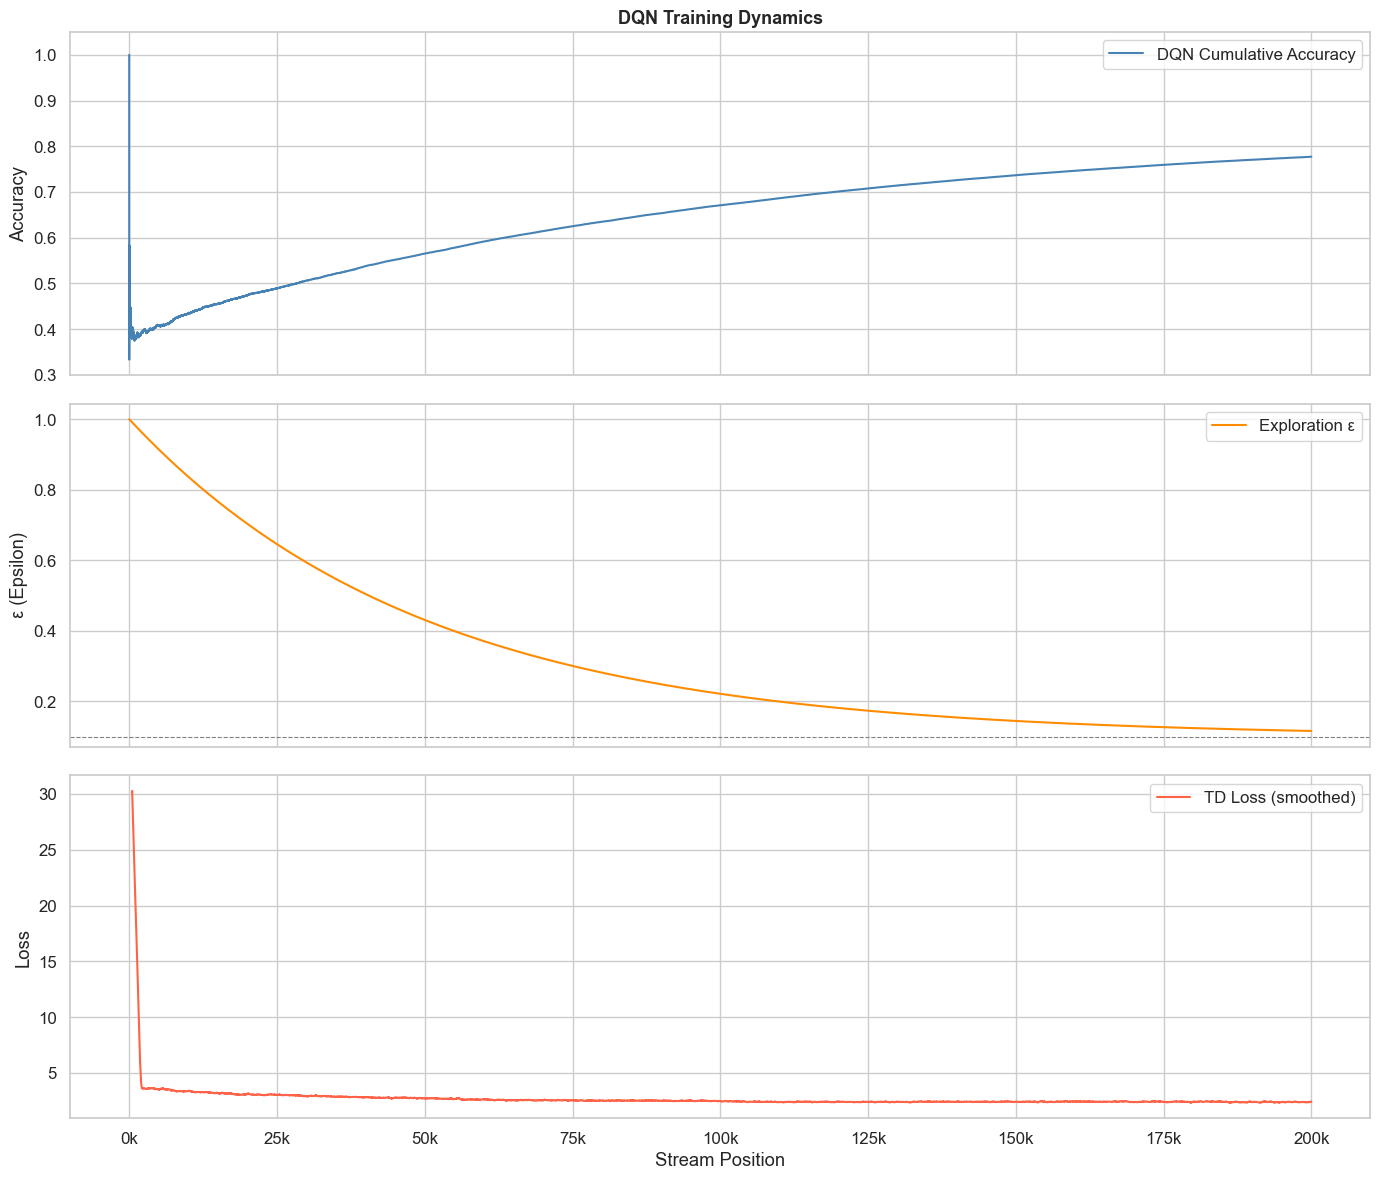

In [38]:
# ---- 9.1 Training dynamics ----
fig, axes = plt.subplots(3, 1, figsize=(14, 12), sharex=True)
xs = np.arange(N_EVAL)

# Rolling accuracy
axes[0].plot(xs, rolling_acc, color='steelblue', lw=1.5, label='DQN Cumulative Accuracy')
axes[0].set_ylabel('Accuracy')
axes[0].set_title('DQN Training Dynamics', fontsize=13, fontweight='bold')
axes[0].legend()
axes[0].set_ylim(0.3, 1.05)

# Epsilon decay
axes[1].plot(xs, eps_log, color='darkorange', lw=1.5, label='Exploration ε')
axes[1].axhline(agent.EPS_END, color='gray', ls='--', lw=0.8)
axes[1].set_ylabel('ε (Epsilon)')
axes[1].legend()

# Loss
smooth_loss = pd.Series(loss_log).rolling(500).mean()
axes[2].plot(xs, smooth_loss, color='tomato', lw=1.5, label='TD Loss (smoothed)')
axes[2].set_ylabel('Loss')
axes[2].set_xlabel('Stream Position')
axes[2].legend()
axes[2].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e3:.0f}k'))

plt.tight_layout()
plt.savefig(FIGS / 'fig11_dqn_training_dynamics.png', dpi=150, bbox_inches='tight')
plt.show()

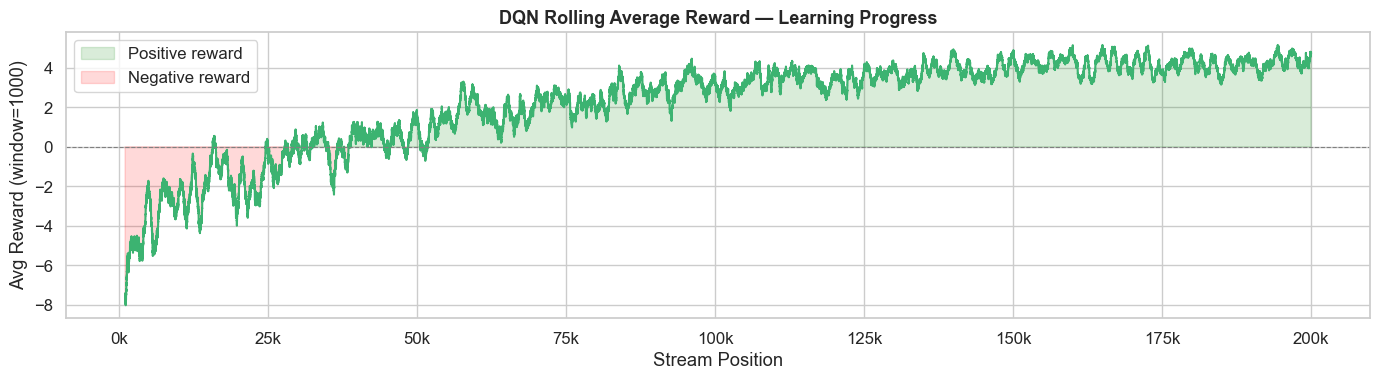

In [39]:
# ---- 9.2 Rolling reward ----
RWIN = 1000
roll_reward = pd.Series(rewards_log).rolling(RWIN).mean()

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(roll_reward, color='mediumseagreen', lw=1.5)
ax.axhline(0, color='gray', ls='--', lw=0.8)
ax.fill_between(np.arange(N_EVAL), roll_reward, 0,
                where=roll_reward >= 0, alpha=0.15, color='green', label='Positive reward')
ax.fill_between(np.arange(N_EVAL), roll_reward, 0,
                where=roll_reward < 0, alpha=0.15, color='red', label='Negative reward')
ax.set_xlabel('Stream Position')
ax.set_ylabel(f'Avg Reward (window={RWIN})')
ax.set_title('DQN Rolling Average Reward — Learning Progress', fontsize=13, fontweight='bold')
ax.legend()
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e3:.0f}k'))
plt.tight_layout()
plt.savefig(FIGS / 'fig12_dqn_rolling_reward.png', dpi=150, bbox_inches='tight')
plt.show()

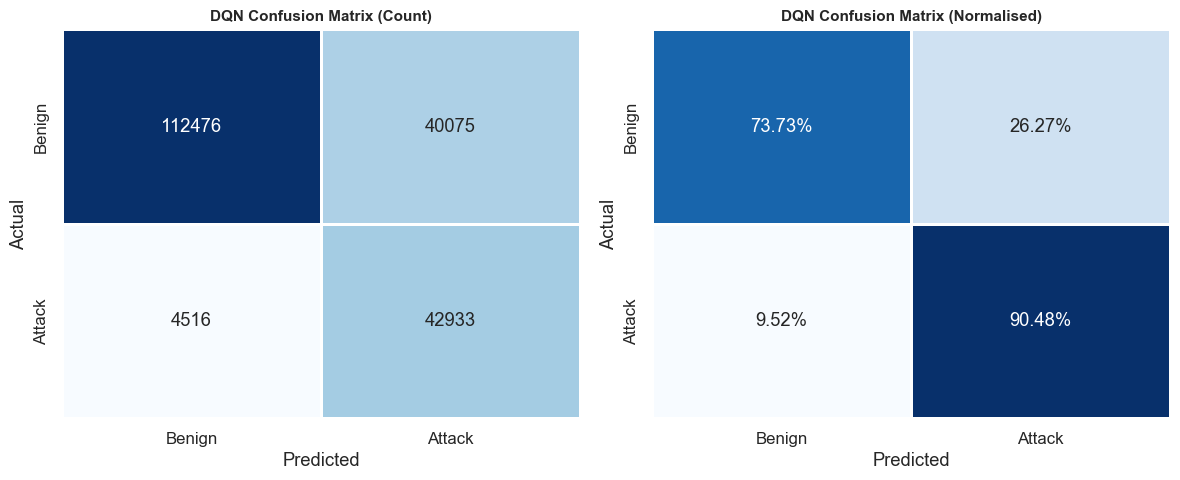

In [40]:
# ---- 9.3 DQN confusion matrix ----
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

cm_counts = confusion_matrix(y_eval, preds_dqn)
cm_norm   = cm_counts.astype(float) / cm_counts.sum(axis=1, keepdims=True)

for ax, data, fmt, title in zip(axes,
                                 [cm_counts, cm_norm],
                                 ['d', '.2%'],
                                 ['Count', 'Normalised']):
    sns.heatmap(data, annot=True, fmt=fmt, cmap='Blues', ax=ax,
                xticklabels=['Benign','Attack'],
                yticklabels=['Benign','Attack'],
                linewidths=1, cbar=False)
    ax.set_title(f'DQN Confusion Matrix ({title})', fontsize=11, fontweight='bold')
    ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')

plt.tight_layout()
plt.savefig(FIGS / 'fig13_dqn_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

**→ Proceed to Notebook 4: Comparative Analysis**